# Noise

In [1]:
import skimage as ski
from skimage.util import random_noise
import skimage.io as io
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from scipy.stats import poisson

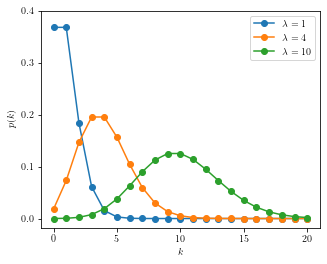

In [2]:
mpl.rcParams['text.usetex'] = True
fig, ax = plt.subplots(1,1, figsize=(5,4))
x = np.arange(21)
for lbd in [1, 4, 10]:
    ax.plot(x, poisson.pmf(x, lbd), '-o', label=f'$\lambda={lbd}$')
plt.legend()
plt.xticks(np.arange(0,21,5))
plt.yticks(np.arange(0,.5,.1))
plt.xlabel('$k$')
plt.ylabel('$p(k)$')
plt.savefig("poisson-distribution.svg", bbox_inches='tight')
plt.show()
mpl.rcParams['text.usetex'] = False

/tmp/ipykernel_323668/2495029713.py:6: RuntimeWarning: divide by zero encountered in double_scalars
  return 10*np.log10(Px/Pb)


Image 0 : RSB = inf dB
Image 1 : RSB = 4.564 dB
Image 2 : RSB = 4.534 dB
Image 3 : RSB = 4.438 dB


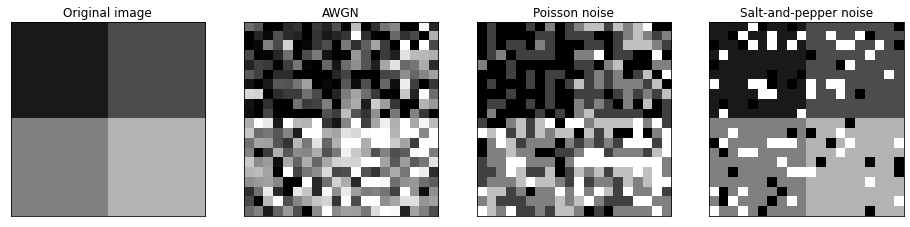

In [3]:
# Exemple de différents bruits de même RSB sur une mire

def rsb(x, y):
    Px = np.linalg.norm(x)**2
    Pb = np.linalg.norm(x-y)**2
    return 10*np.log10(Px/Pb)

# Images
N = 10
coeffs = np.array([[.1, .3], [.5, .7]])
pattern = np.ones((N,N))
x = np.kron(coeffs, pattern)
imgs = [
    x,
    random_noise(x, mode="gaussian", clip=True, mean=0, var=0.11),
    random_noise(x, mode="poisson", clip=True),
    random_noise(x, mode="s&p", clip=False, amount=.23)
]
tit = ["Original image", "AWGN", "Poisson noise", "Salt-and-pepper noise"]

# Affichage
fig, ax = plt.subplots(1,4,figsize=(16,4))
for i in range(4):
    ax[i].imshow(imgs[i], cmap="gray", vmin=0, vmax=1)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].set_title(tit[i])
    print(f"Image {i} : RSB = {rsb(x,imgs[i]):.3f} dB")

plt.savefig("three-noises.svg", bbox_inches='tight')

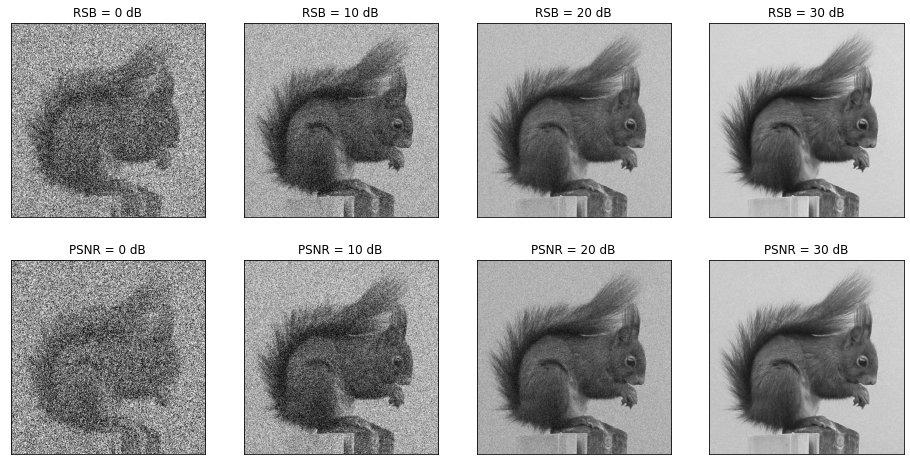

In [4]:
# La même image à différents niveaux de bruit

# Charge l'image, la convertit entre -1 et 1
x = io.imread("squirrel.png")
x = ski.img_as_float(x)

# Puissance et dynamique de l'image
(M, N) = x.shape
Px = np.linalg.norm(x)**2/(M*N)
dx = x.max() - x.min()

# Valeurs des RSB et PSNR
n = [0, 10, 20, 30]

# Tableaux
imgs = []
tit = []

# RSB
for i in range(4):
    v = Px * 10**(-n[i]/10)
    y = random_noise(x, mode="gaussian", mean=0, var=v)
    imgs.append(y)
    tit.append(f"RSB = {n[i]} dB")

# PSNR
for i in range(4):
    v = dx**2 * 10**(-n[i]/10)
    y = random_noise(x, mode="gaussian", mean=0, var=v)
    imgs.append(y)
    tit.append(f"PSNR = {n[i]} dB")

# Affichage
fig, ax = plt.subplots(2,4,figsize=(16,8))
ax = ax.flatten()
for i in range(8):
    ax[i].imshow(imgs[i], cmap="gray")
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].set_title(tit[i])
    
plt.savefig("snr-psnr.svg", bbox_inches='tight')